<a href="https://colab.research.google.com/github/cchen744/lst-htindex-compare/blob/b1-census_tract/lst-analysis/LST_analysis_JJA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LST Analysis: Houston vs Houston vs Phoenix (JJA 2020-2024)

Comparing Land Surface Temperature patterns across humid (Houston) and arid (Phoenix) urban environments using MODIS MOD11A1 satellite data.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
import ee
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance_matrix
import libpysal as ps
from esda import Moran
import os

try:
    ee.Initialize()
except:
    ee.Authenticate()
    ee.Initialize(project='extremeweatheruhi')

print("✓ GEE initialized")

✓ GEE initialized


In [3]:
# !git clone https://github.com/cchen744/lst-htindex-compare.git -q
# Now pull from branch using census tract
!git clone -b b1-census_tract https://github.com/cchen744/lst-htindex-compare.git -q

In [45]:
import sys

if 'lst_pipeline' in sys.modules:
    del sys.modules['lst_pipeline']

sys.path.insert(0, './lst-htindex-compare/lst-analysis')
from lst_pipeline import create_config, JJALSTPipeline, GEELSTFetcher
print("✓ Pipeline imported")

✓ Pipeline imported


In [17]:
import geopandas as gpd

# get geometry
az_url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_04_place_500k.zip"
fl_url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_12_place_500k.zip"
tx_url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_48_place_500k.zip"

az_places = gpd.read_file(az_url)
fl_places = gpd.read_file(fl_url)
tx_places = gpd.read_file(tx_url)

phoenix_geom = az_places[az_places['NAME'] == 'Phoenix'].geometry.iloc[0]
houston_geom = fl_places[fl_places['NAME'] == 'Houston'].geometry.iloc[0]
houston_geom = tx_places[tx_places['NAME'] == 'Houston'].geometry.iloc[0]

# save to config
config_phoenix = create_config('Phoenix', use_census_tract=True)
config_houston = create_config('Houston', use_census_tract=True)
config_houston = create_config('Houston', use_census_tract=True)

config_phoenix.census_geom = phoenix_geom
config_miami.census_geom = miami_geom
config_houston.census_geom = houston_geom

In [18]:
os.makedirs('./outputs', exist_ok=True)

In [19]:
print("\nRunning Houston analysis...")
houston_pipeline = JJALSTPipeline(config_houston)  # use previous config adapted to TIGER
houston_results = houston_pipeline.run(export_geotiff=True)
houston_stats = houston_results['statistics']
print(houston_stats)


Running Houston analysis...
GEE initialization note: ee.Initialize: no project found. Call with project= or see http://goo.gle/ee-auth.

JJA LST Analysis Pipeline: Houston
Period: 2020-2024
Months: June, July, August

Step 1: Fetching MODIS JJA LST data...
  2020 JJA: fetched
  2021 JJA: fetched
  2022 JJA: fetched
  2023 JJA: fetched
  2024 JJA: fetched
Step 2: Computing statistics...
Step 3: Exporting maps...
Exporting Houston JJA LST to Google Drive...
  → Download from Google Drive when ready
Step 4: Exporting statistics...
  → Statistics: outputs/Houston/Houston_JJA_statistics.csv
  → Output dir: outputs/Houston

✓ Pipeline complete!

   year season  mean_temp_c  median_temp_c  std_temp_c  min_temp_c  \
0  2020    JJA    37.412955      38.083676    2.589292       28.05   
1  2021    JJA    36.260779      36.794927    2.432303       27.43   
2  2022    JJA    38.144178      38.885389    2.489713       27.95   
3  2023    JJA    38.030455      38.715336    2.312703       29.21   
4

In [20]:
print("\nRunning Miami analysis...")
houston_pipeline = JJALSTPipeline(config_miami)  # use previous config adapted to TIGER
miami_results = miami_pipeline.run(export_geotiff=True)
miami_stats = miami_results['statistics']
print(miami_stats)


Running Miami analysis...
GEE initialization note: ee.Initialize: no project found. Call with project= or see http://goo.gle/ee-auth.

JJA LST Analysis Pipeline: Miami
Period: 2020-2024
Months: June, July, August

Step 1: Fetching MODIS JJA LST data...
  2020 JJA: fetched
  2021 JJA: fetched
  2022 JJA: fetched
  2023 JJA: fetched
  2024 JJA: fetched
Step 2: Computing statistics...
Step 3: Exporting maps...
Exporting Miami JJA LST to Google Drive...
  → Download from Google Drive when ready
Step 4: Exporting statistics...
  → Statistics: outputs/Miami/Miami_JJA_statistics.csv
  → Output dir: outputs/Miami

✓ Pipeline complete!

   year season  mean_temp_c  median_temp_c  std_temp_c  min_temp_c  \
0  2020    JJA    37.126775      37.454204    2.181806       28.97   
1  2021    JJA    35.792752      35.850000    1.991515       28.61   
2  2022    JJA    36.539830      36.878257    2.234446       27.75   
3  2023    JJA    35.253374      35.610000    1.642911       28.93   
4  2024    JJ

In [21]:
print("\nRunning Phoenix analysis...")
phoenix_pipeline = JJALSTPipeline(config_phoenix)  # use previous config adapted to TIGER
phoenix_results = phoenix_pipeline.run(export_geotiff=True)
phoenix_stats = phoenix_results['statistics']
print(phoenix_stats)


Running Phoenix analysis...
GEE initialization note: ee.Initialize: no project found. Call with project= or see http://goo.gle/ee-auth.

JJA LST Analysis Pipeline: Phoenix
Period: 2020-2024
Months: June, July, August

Step 1: Fetching MODIS JJA LST data...
  2020 JJA: fetched
  2021 JJA: fetched
  2022 JJA: fetched
  2023 JJA: fetched
  2024 JJA: fetched
Step 2: Computing statistics...
Step 3: Exporting maps...
Exporting Phoenix JJA LST to Google Drive...
  → Download from Google Drive when ready
Step 4: Exporting statistics...
  → Statistics: outputs/Phoenix/Phoenix_JJA_statistics.csv
  → Output dir: outputs/Phoenix

✓ Pipeline complete!

   year season  mean_temp_c  median_temp_c  std_temp_c  min_temp_c  \
0  2020    JJA    51.724585      51.860913    1.340366   45.440000   
1  2021    JJA    49.716271      49.738695    1.295717   43.750000   
2  2022    JJA    49.984128      50.074036    1.564367   43.530000   
3  2023    JJA    49.862086      50.024139    1.252802   43.440000   
4

In [22]:
houston_stats['city'] = 'Houston'
phoenix_stats['city'] = 'Phoenix'
combined = pd.concat([houston_stats, phoenix_stats], ignore_index=True)
print(combined)

   year season  mean_temp_c  median_temp_c  std_temp_c  min_temp_c  \
0  2020    JJA    37.412955      38.083676    2.589292   28.050000   
1  2021    JJA    36.260779      36.794927    2.432303   27.430000   
2  2022    JJA    38.144178      38.885389    2.489713   27.950000   
3  2023    JJA    38.030455      38.715336    2.312703   29.210000   
4  2024    JJA    36.182523      36.730764    2.318350   28.090000   
5  2020    JJA    51.724585      51.860913    1.340366   45.440000   
6  2021    JJA    49.716271      49.738695    1.295717   43.750000   
7  2022    JJA    49.984128      50.074036    1.564367   43.530000   
8  2023    JJA    49.862086      50.024139    1.252802   43.440000   
9  2024    JJA    48.434129      48.498549    1.264652   43.116667   

   max_temp_c  temp_range_c     city  
0   42.770000        14.720  Houston  
1   40.870000        13.440  Houston  
2   42.420000        14.470  Houston  
3   42.360000        13.150  Houston  
4   40.770000        12.680  Houst

## Moran's I

In [25]:
def compute_morans_i(image, region, city_name, num_samples=150):
    bounds = region.bounds().getInfo()
    coords_list = bounds['coordinates'][0]
    lons = [c[0] for c in coords_list]
    lats = [c[1] for c in coords_list]

    grid_size = int(np.sqrt(num_samples))
    lons_grid = np.linspace(min(lons), max(lons), grid_size)
    lats_grid = np.linspace(min(lats), max(lats), grid_size)

    points = [ee.Geometry.Point([lon, lat]) for lon in lons_grid for lat in lats_grid]
    sampled = image.sample(region=ee.FeatureCollection(points), scale=1000)
    values = sampled.aggregate_array(config_houston.lst_band).getInfo()

    temps_c = np.array([v * 0.02 - 273.15 for v in values if v])
    coords = np.array([[lons_grid[i % grid_size], lats_grid[i // grid_size]]
                       for i in range(len(points))])[:len(temps_c)]

    weights = ps.weights.KNN.from_array(coords, k=5)
    mi = Moran(temps_c, weights)
    return {'city': city_name, 'morans_i': mi.I, 'p_value': mi.p_norm}

print("Computing Moran's I...")
houston_jja_mean = ee.ImageCollection(list(houston_results['jja_data_gee'].values())).mean()
phoenix_jja_mean = ee.ImageCollection(list(phoenix_results['jja_data_gee'].values())).mean()

houston_mi = compute_morans_i(houston_jja_mean, config_houston.create_geom(), 'Houston')
phoenix_mi = compute_morans_i(phoenix_jja_mean, config_phoenix.create_geom(), 'Phoenix')
morans_df = pd.DataFrame([houston_mi, phoenix_mi])
print(morans_df)

Computing Moran's I...
      city  morans_i       p_value
0  Houston  0.547036  4.766311e-29
1  Phoenix  0.414806  1.361729e-17


## Hotspot

In [28]:
def get_hotspot_pct(image, region):
    threshold = image.reduceRegion(ee.Reducer.percentile([75]), region, scale=1000).getInfo()
    threshold_val = list(threshold.values())[0]
    hotspot_mask = image.gte(threshold_val)
    total_pixels = image.reduceRegion(ee.Reducer.count(), region, 1000).getInfo()
    hotspot_pixels = hotspot_mask.reduceRegion(ee.Reducer.sum(), region, 1000).getInfo()
    count = list(total_pixels.values())[0]
    hotspots = list(hotspot_pixels.values())[0]
    return (hotspots / count * 100) if count > 0 else 0

houston_hotspot = get_hotspot_pct(houston_jja_mean, config_houston.create_geom())
phoenix_hotspot = get_hotspot_pct(phoenix_jja_mean, config_phoenix.create_geom())
print(f"Houston: {houston_hotspot:.2f}%, Phoenix: {phoenix_hotspot:.2f}%")

Houston: 25.10%, Phoenix: 24.33%


In [47]:
# hotspot map
# After downloading GeoTIFF from Google Drive to local folder
from lst_pipeline import LSTVisualizer

houston_geotiff_path = '/content/drive/MyDrive/LST_maps/Houston_JJA_LST_2020_2024.tif'
phoenix_geotiff_path = '/content/drive/MyDrive/LST_maps/Phoenix_JJA_LST_2020_2024.tif'


LSTVisualizer.create_hotspot_map(
    houston_geotiff_path,
    'Houston',
    './outputs/Houston_hotspot_map.html',
    city_center=[29.76, -95.37],
    census_geom=houston_geom
)

LSTVisualizer.create_hotspot_map(
    phoenix_geotiff_path,
    'Phoenix',
    './outputs/Phoenix_hotspot_map.html',
    city_center=[33.425, -112.075],
    census_geom=phoenix_geom
)

Masked to Census Tract: (-95.91312288544131, 29.51414865974688, -95.01031602490119, 30.15644408789234)
Map saved to ./outputs/Houston_hotspot_map.html
Masked to Census Tract: (-112.32534312630497, 33.28707285304887, -111.9211012484512, 33.92038512835313)
Map saved to ./outputs/Phoenix_hotspot_map.html


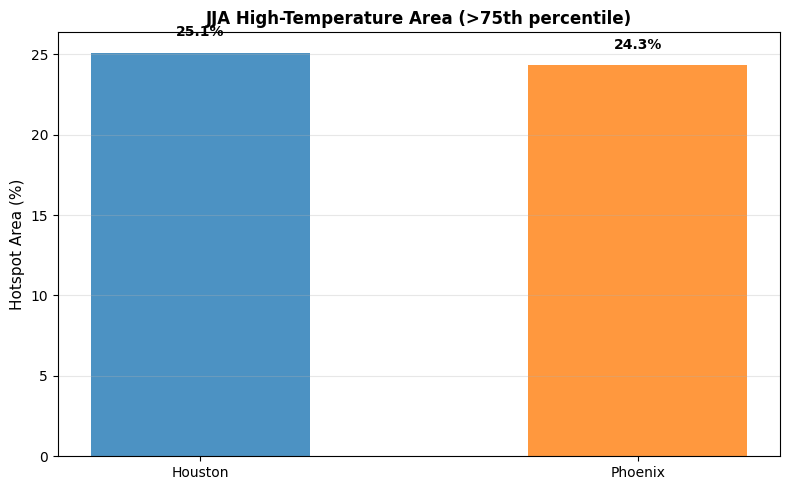

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
cities = ['Houston', 'Phoenix']
hotspots = [houston_hotspot, phoenix_hotspot]
bars = ax.bar(cities, hotspots, color=['#1f77b4', '#ff7f0e'], alpha=0.8, width=0.5)
ax.set_ylabel('Hotspot Area (%)', fontsize=11)
ax.set_title('JJA High-Temperature Area (>75th percentile)', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
for bar, v in zip(bars, hotspots):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/hotspot_jja_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Spatial Variability

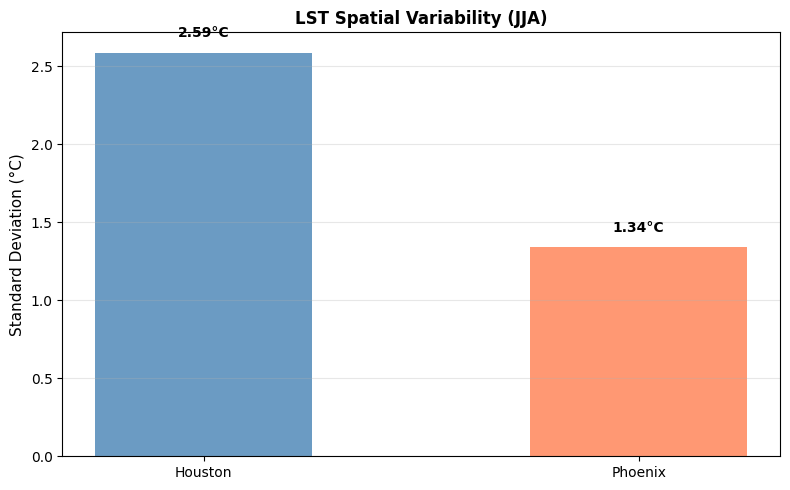

In [31]:
houston_std = houston_stats['std_temp_c'].values[0]
phoenix_std = phoenix_stats['std_temp_c'].values[0]
fig, ax = plt.subplots(figsize=(8, 5))
cities = ['Houston', 'Phoenix']
stds = [houston_std, phoenix_std]
bars = ax.bar(cities, stds, color=['steelblue', 'coral'], alpha=0.8, width=0.5)
ax.set_ylabel('Standard Deviation (°C)', fontsize=11)
ax.set_title('LST Spatial Variability (JJA)', fontweight='bold', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
for bar, v in zip(bars, stds):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.1, f'{v:.2f}°C', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/temperature_variability.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings and Interpretation

In [32]:
houston_mean = houston_stats['mean_temp_c'].mean()
phoenix_mean = phoenix_stats['mean_temp_c'].mean()
temp_diff = phoenix_mean - houston_mean
houston_yearly = houston_stats.groupby('year')['mean_temp_c'].mean()
phoenix_yearly = phoenix_stats.groupby('year')['mean_temp_c'].mean()
houston_trend = np.polyfit(houston_yearly.index, houston_yearly.values, 1)[0]
phoenix_trend = np.polyfit(phoenix_yearly.index, phoenix_yearly.values, 1)[0]

print("\n" + "="*70)
print("KEY FINDINGS: LST Comparison Houston vs Phoenix (JJA 2020-2024)")
print("="*70)
print(f"\n1. ABSOLUTE TEMPERATURE (JJA):")
print(f"   Houston: {houston_mean:.2f}°C, Phoenix: {phoenix_mean:.2f}°C (Δ={temp_diff:+.2f}°C)")
print(f"\n2. WARMING TREND: Houston {houston_trend:+.4f}°C/year, Phoenix {phoenix_trend:+.4f}°C/year")
print(f"\n3. SPATIAL VARIABILITY: Houston {houston_std:.2f}°C, Phoenix {phoenix_std:.2f}°C")
print(f"\n4. SPATIAL AUTOCORRELATION (Moran's I): Houston {morans_df.loc[0, 'morans_i']:.3f}, Phoenix {morans_df.loc[1, 'morans_i']:.3f}")
print(f"\n5. HIGH-TEMPERATURE AREAS: Houston {houston_hotspot:.1f}%, Phoenix {phoenix_hotspot:.1f}%")
print("\n" + "="*70)


KEY FINDINGS: LST Comparison Houston vs Phoenix (JJA 2020-2024)

1. ABSOLUTE TEMPERATURE (JJA):
   Houston: 37.21°C, Phoenix: 49.94°C (Δ=+12.74°C)

2. WARMING TREND: Houston -0.0691°C/year, Phoenix -0.6435°C/year

3. SPATIAL VARIABILITY: Houston 2.59°C, Phoenix 1.34°C

4. SPATIAL AUTOCORRELATION (Moran's I): Houston 0.547, Phoenix 0.415

5. HIGH-TEMPERATURE AREAS: Houston 25.1%, Phoenix 24.3%



In [33]:
combined_final = pd.concat([houston_stats.assign(city='Houston'), phoenix_stats.assign(city='Phoenix')], ignore_index=True)
combined_final.to_csv('./outputs/LST_combined_statistics.csv', index=False)

summary = f"""LST ANALYSIS SUMMARY: Houston vs Phoenix (JJA 2020-2024)
{'='*60}
Temperature: Houston {houston_mean:.2f}°C, Phoenix {phoenix_mean:.2f}°C (Δ{temp_diff:+.2f}°C)
Trend: Houston {houston_trend:+.4f}°C/year, Phoenix {phoenix_trend:+.4f}°C/year
Variability: Houston {houston_std:.2f}°C, Phoenix {phoenix_std:.2f}°C
Moran's I: Houston {morans_df.loc[0, 'morans_i']:.3f}, Phoenix {morans_df.loc[1, 'morans_i']:.3f}
Hotspots: Houston {houston_hotspot:.1f}%, Phoenix {phoenix_hotspot:.1f}%
Data: MODIS/061/MOD11A1, {pd.Timestamp.now().strftime('%Y-%m-%d')}
"""

with open('./outputs/LST_analysis_summary.txt', 'w') as f:
    f.write(summary)

print("✓ Exported: LST_combined_statistics.csv, LST_analysis_summary.txt")
print(summary)

✓ Exported: LST_combined_statistics.csv, LST_analysis_summary.txt
LST ANALYSIS SUMMARY: Houston vs Phoenix (JJA 2020-2024)
Temperature: Houston 37.21°C, Phoenix 49.94°C (Δ+12.74°C)
Trend: Houston -0.0691°C/year, Phoenix -0.6435°C/year
Variability: Houston 2.59°C, Phoenix 1.34°C
Moran's I: Houston 0.547, Phoenix 0.415
Hotspots: Houston 25.1%, Phoenix 24.3%
Data: MODIS/061/MOD11A1, 2026-04-28

